# Notebook for X-Ray Light curve model Project

In [4]:
from plot_results import *
from chandra_phase_analysis import *
from compute_flux_vs_nH import *
from xrb_lightcurve import *
import pandas as pd
import numpy as np
import os
from xspec import (
        AllData,
        AllModels,
        Spectrum,
        Model,
        Fit,
        Xset,
        Plot,
)

## Single ObsID 15803 LC fitting

### Soft Band (0.5 - 2.0 KeV)

Loading 1 observation file(s) from ./data/IC_10_X1_LC_CIAO/soft/single
Removed 131 zero/NaN flux data points (1367 remaining)


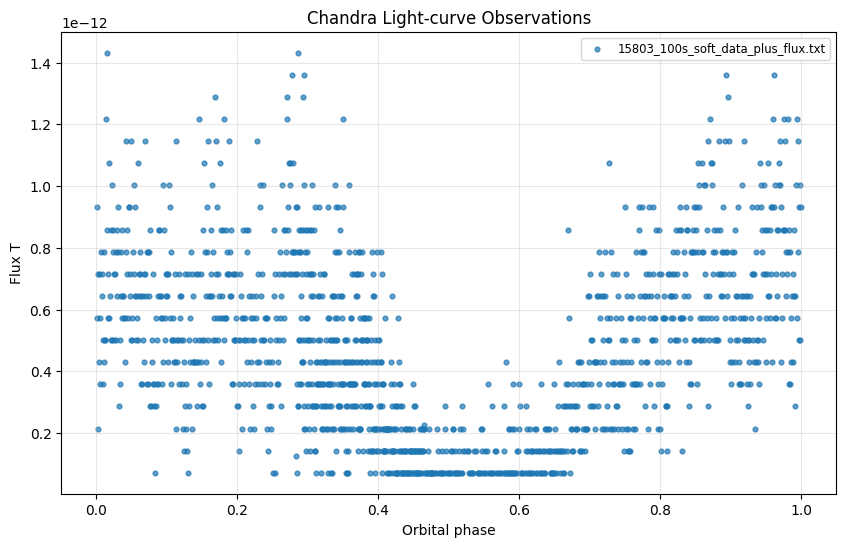

In [5]:
# Plot soft band LC
obs_column = "flux_t"
time_column = "t_raw"
df = load_data("./data/IC_10_X1_LC_CIAO/soft/single", obs_column = obs_column, time_column = time_column)
n_before = len(df)
df = df[(df['rate'] != 0) & (df['rate'].notna())].reset_index(drop=True)
n_removed = n_before - len(df)
if n_removed > 0:
    print(f"Removed {n_removed} zero/NaN flux data points ({len(df)} remaining)")
plot_phase(df, None, obs_column_name = obs_column)

#### Constant Velocity Wind best fit

In [7]:
df['phase2'] = frac((df['time'] - 278800407.267) / 125431)
df.head()

,rate,time,error,phase,obs,phase2
0,1.249350e-13,5.317035e+08,1.249350e-13,0.283627,15803_100s_soft_data_plus_flux.txt,0.273031
1,3.580054e-13,5.317036e+08,3.580054e-13,0.284424,15803_100s_soft_data_plus_flux.txt,0.273828
2,7.160108e-14,5.317037e+08,7.160108e-14,0.285221,15803_100s_soft_data_plus_flux.txt,0.274625
3,2.864043e-13,5.317038e+08,2.864043e-13,0.286019,15803_100s_soft_data_plus_flux.txt,0.275422
4,2.864043e-13,5.317039e+08,2.864043e-13,0.286816,15803_100s_soft_data_plus_flux.txt,0.276220


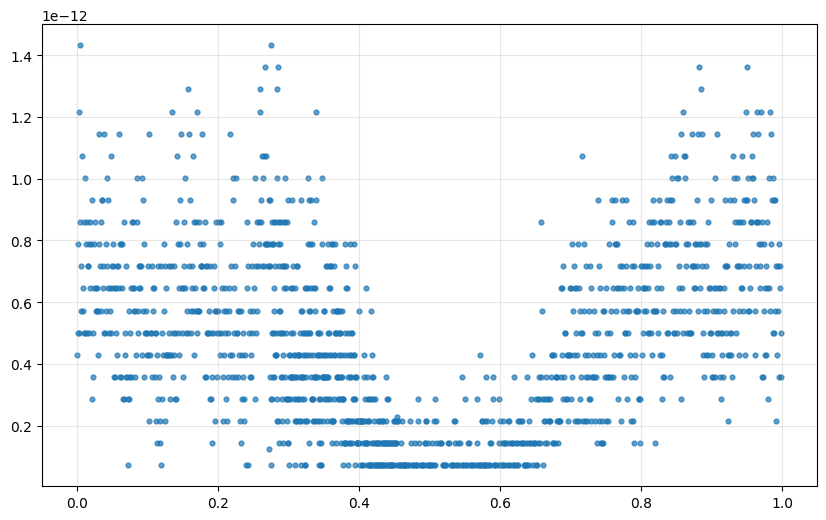

In [10]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
ax = plt.gca()
ax.scatter(df["phase2"], df["rate"], s=12, alpha=0.7)
ax.grid(alpha=0.3)

Loading 1 observation file(s) from ./data/IC_10_X1_LC_CIAO/soft/single
Removed 131 zero/NaN flux data points (1367 remaining)


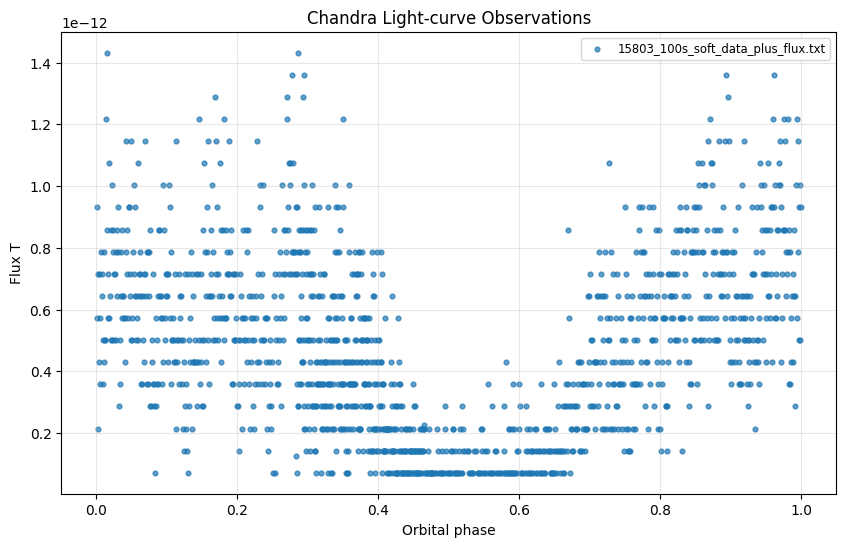

In [5]:
# Plot soft band LC
obs_column = "flux_t"
time_column = "t_raw"
df = load_data("./data/IC_10_X1_LC_CIAO/soft/single", obs_column = obs_column, time_column = time_column, phase_column=None)
n_before = len(df)
df = df[(df['rate'] != 0) & (df['rate'].notna())].reset_index(drop=True)
n_removed = n_before - len(df)
if n_removed > 0:
    print(f"Removed {n_removed} zero/NaN flux data points ({len(df)} remaining)")
plot_phase(df, None, obs_column_name = obs_column)

In [7]:
# Generate Model LC from MCMC fit
os.system("python xrb_lightcurve.py \
--flux_method interpolate \
--flux_csv ./analyses/flux_vs_nH_tbabs_15803_soft.csv \
--output ./analyses/sim_flux_mcmc_tbabs_15803_soft.csv \
--i0 22.625344 --lam 0.533545 --lam2 0.533545 --r 0.074665 --R 2.620185 --d1 1.909942 --d2 1.907222 --converge-rmax")

/Users/rpanchal/Desktop/xrb_lc/XRB_LightCurve/xrb_lightcurve.py:531: UserWarning: Some nH values are outside CSV range [0.010, 100.000] 1e22 cm^-2 for band 'soft'. Extrapolation will be used (fill_value='extrapolate').
  warnings.warn(
/Users/rpanchal/Desktop/xrb_lc/XRB_LightCurve/xrb_lightcurve.py:531: UserWarning: Some nH values are outside CSV range [0.010, 100.000] 1e22 cm^-2 for band 'soft'. Extrapolation will be used (fill_value='extrapolate').
  warnings.warn(


Starting XRB Lightcurve Simulation...
Parameters:
  r (emitter radius): 0.074665 solar radii
  R (companion radius): 2.620185 solar radii
  d1 (emitter separation): 1.909942 solar radii
  d2 (companion separation): 1.907222 solar radii
  gma0 (starting phase): -90.0 degrees
  i0 (inclination): 22.625344 degrees
  dth (orbital increment): 1.0 degrees
  d2h (polar cell size): 6.0 degrees
  dz (LOS step size): 0.1
  Rmax (LOS cutoff): 7.634328
  converge_rmax: True
  n_jobs (parallel workers): 1
  flux_method: interpolate
  flux_csv: ./analyses/flux_vs_nH_tbabs_15803_soft.csv
  flux_type: erg
  lam: 0.533545
  lam2: 0.533545
  Output file: ./analyses/sim_flux_mcmc_tbabs_15803_soft.csv

Detected energy bands in CSV: soft

Simulation completed! Results saved to ./analyses/sim_flux_mcmc_tbabs_15803_soft.csv
Total data points: 360
Phase range: -90.00 to 269.00 degrees


0

Phase binning: 1367 points -> 144 bins (avg 9.1 points/bin)

Fitting column: nfl_soft_av
Chi-square (no rescaling):
  Phase shift = 0.00000 (fixed)
  Scale factor = 1.00000 (fixed)
  Reduced χ² = 3.219

Fitting column: nfl_soft_cv
Chi-square (no rescaling):
  Phase shift = 0.00000 (fixed)
  Scale factor = 1.00000 (fixed)
  Reduced χ² = 3.278


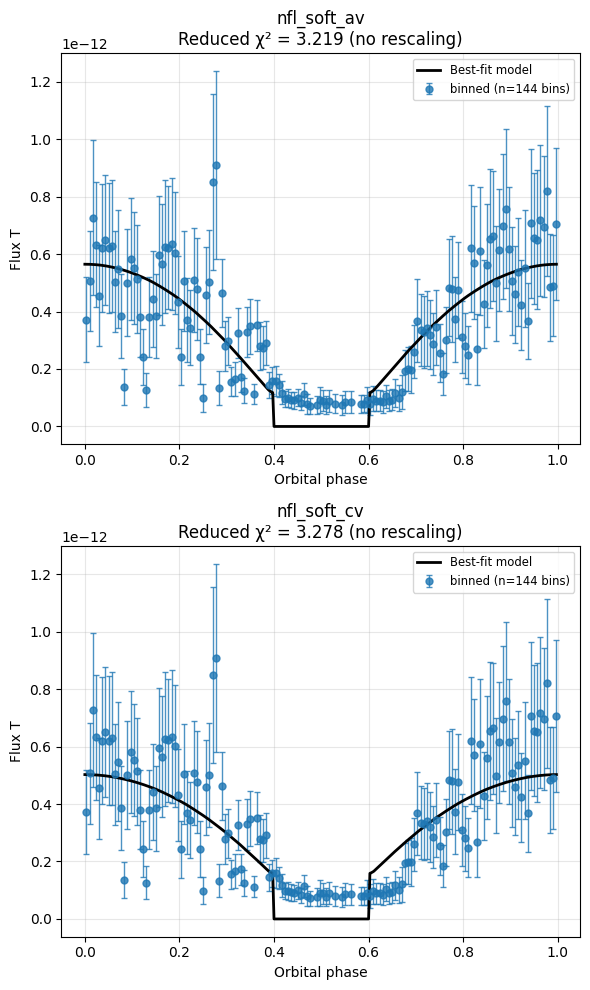

In [9]:
# Fit MCMC model to data
sim_df = pd.read_csv("./analyses/sim_flux_mcmc_tbabs_15803_soft.csv")
sim_columns = detect_flux_columns(sim_df)
fit_results = []
no_phase_bin = False
if not no_phase_bin:
        df = phase_bin_data(
            df,
            n_bins=150,
            min_points_per_bin=5,
            rate_column='rate',
            error_column='error',
            verbose=True
        )
        is_binned = True
for col in sim_columns:
    print(f"\n{'='*60}")
    print(f"Fitting column: {col}")
    print('='*60)
    try:
        shift, scale, chi2 = fit_simulation(df, sim_df, col, rescale=False)
        fit_results.append((shift, scale, chi2))
    except:
        None
if len(sim_columns) == 1:
    # Single column: use original plot
    shift, scale, chi2 = fit_results[0]
    plot_phase(df, None, sim_df, shift, scale, sim_columns[0], chi2, 
                rescaled=False, obs_column_name=obs_column, is_binned=is_binned)
else:
    # Multiple columns: use grid plot
    plot_multi_column_fits(df, None, sim_df, sim_columns, fit_results, 
                            rescaled=False, obs_column_name=obs_column, is_binned=is_binned)

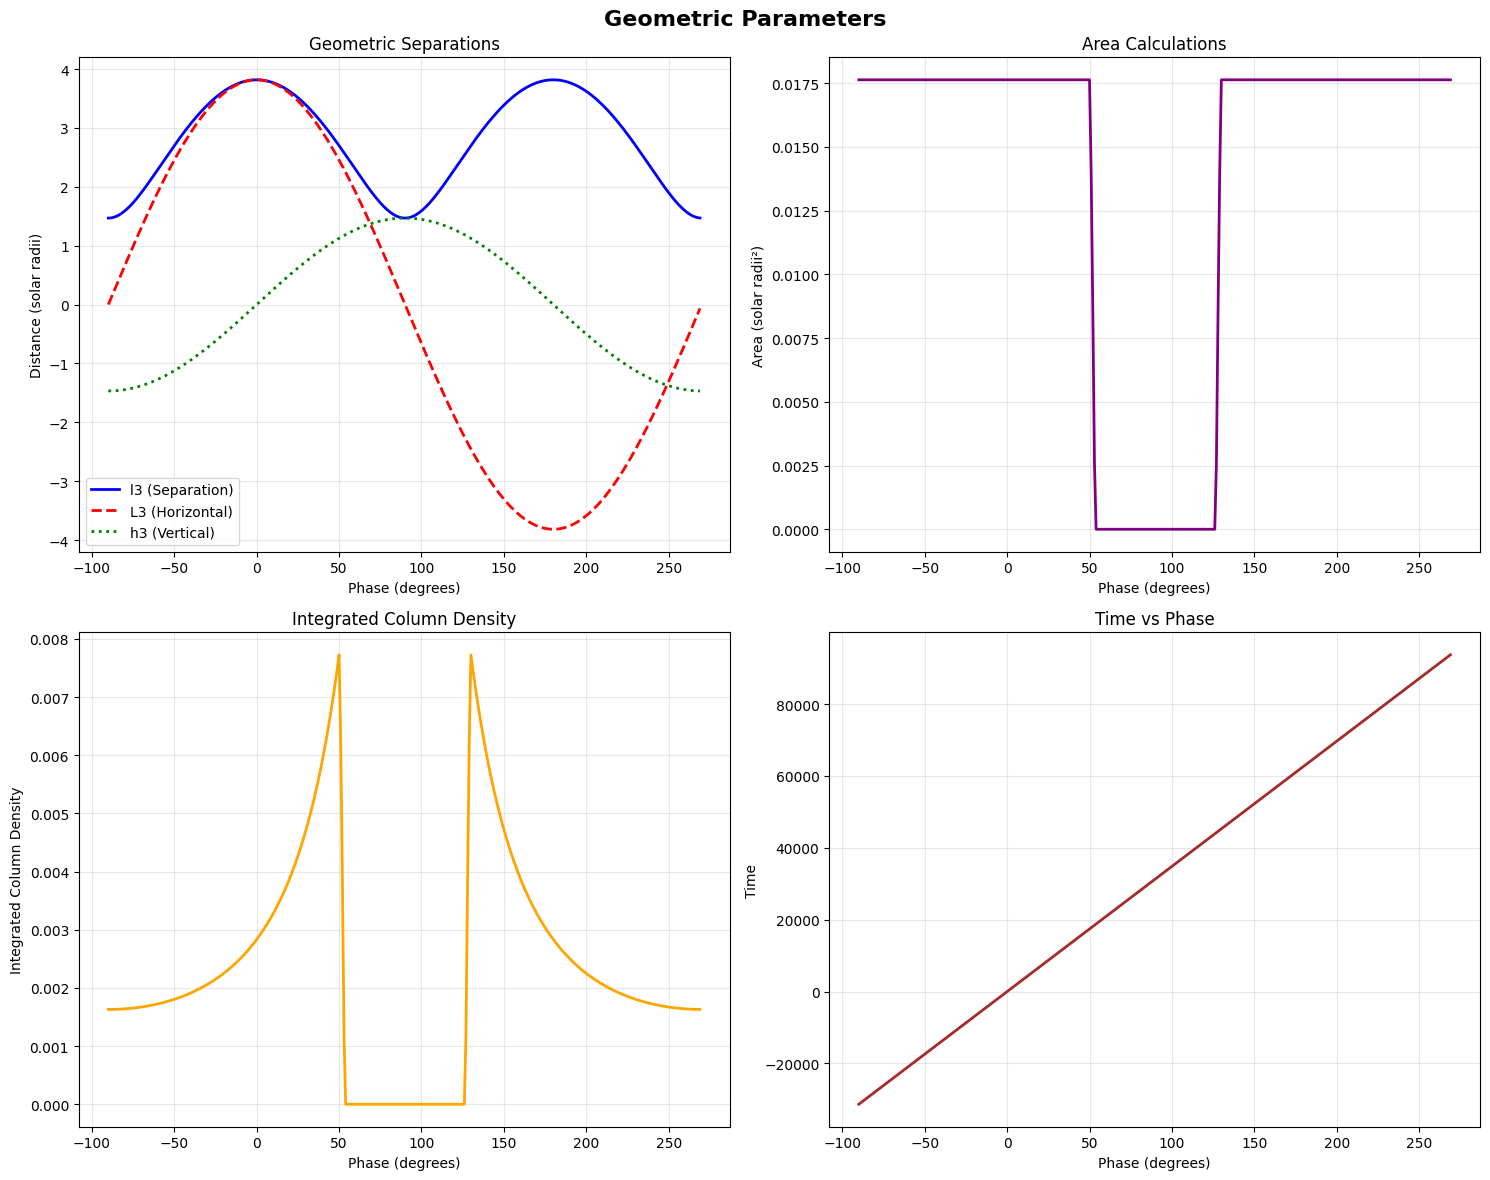

In [7]:
plot_geometric_parameters("./analyses/sim_flux_mcmc_tbabs_15803_soft.csv")

#### Constant accelerating wind best fit

In [4]:
# Generate Model LC from MCMC fit
os.system("python xrb_lightcurve.py \
--flux_method interpolate \
--flux_csv ./analyses/flux_vs_nH_tbabs_600bin_15803_soft.csv \
--output ./analyses/sim_flux_mcmc_tbabs_15803_av_soft.csv \
--i0 29.197533 --lam 0.533545 --lam2 0.533545 --r 0.117085 --R 1.995164 --d1 2.238081 --d2 1.706841 --converge-rmax")

Starting XRB Lightcurve Simulation...
Parameters:
  r (emitter radius): 0.117085 solar radii
  R (companion radius): 1.995164 solar radii
  d1 (emitter separation): 2.238081 solar radii
  d2 (companion separation): 1.706841 solar radii
  gma0 (starting phase): -90.0 degrees
  i0 (inclination): 29.197533 degrees
  dth (orbital increment): 1.0 degrees
  d2h (polar cell size): 6.0 degrees
  dz (LOS step size): 0.1
  Rmax (LOS cutoff): 7.889844
  converge_rmax: True
  n_jobs (parallel workers): 1
  flux_method: interpolate
  flux_csv: ./analyses/flux_vs_nH_tbabs_600bin_15803_soft.csv
  flux_type: erg
  lam: 0.533545
  lam2: 0.533545
  Output file: ./analyses/sim_flux_mcmc_tbabs_15803_av_soft.csv

Detected energy bands in CSV: soft

Simulation completed! Results saved to ./analyses/sim_flux_mcmc_tbabs_15803_av_soft.csv
Total data points: 360
Phase range: -90.00 to 269.00 degrees


0

Phase binning: 1367 points -> 144 bins (avg 9.1 points/bin)

Fitting column: nfl_soft_av
Chi-square (no rescaling):
  Phase shift = 0.00000 (fixed)
  Scale factor = 1.00000 (fixed)
  Reduced χ² = 11.750

Fitting column: nfl_soft_cv
Chi-square (no rescaling):
  Phase shift = 0.00000 (fixed)
  Scale factor = 1.00000 (fixed)
  Reduced χ² = 10.877


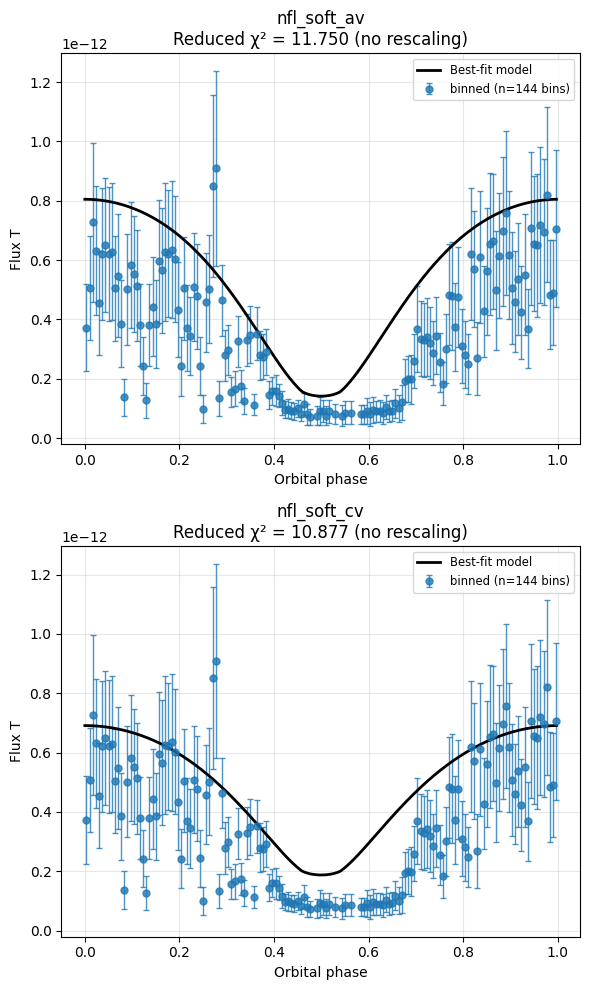

In [6]:
# Fit MCMC model to data
sim_df = pd.read_csv("./analyses/sim_flux_mcmc_tbabs_15803_av_soft.csv")
sim_columns = detect_flux_columns(sim_df)
fit_results = []
no_phase_bin = False
if not no_phase_bin:
        df = phase_bin_data(
            df,
            n_bins=150,
            min_points_per_bin=5,
            rate_column='rate',
            error_column='error',
            verbose=True
        )
        is_binned = True
for col in sim_columns:
    print(f"\n{'='*60}")
    print(f"Fitting column: {col}")
    print('='*60)
    try:
        shift, scale, chi2 = fit_simulation(df, sim_df, col, rescale=False)
        fit_results.append((shift, scale, chi2))
    except:
        None
if len(sim_columns) == 1:
    # Single column: use original plot
    shift, scale, chi2 = fit_results[0]
    plot_phase(df, None, sim_df, shift, scale, sim_columns[0], chi2, 
                rescaled=False, obs_column_name=obs_column, is_binned=is_binned)
else:
    # Multiple columns: use grid plot
    plot_multi_column_fits(df, None, sim_df, sim_columns, fit_results, 
                            rescaled=False, obs_column_name=obs_column, is_binned=is_binned)

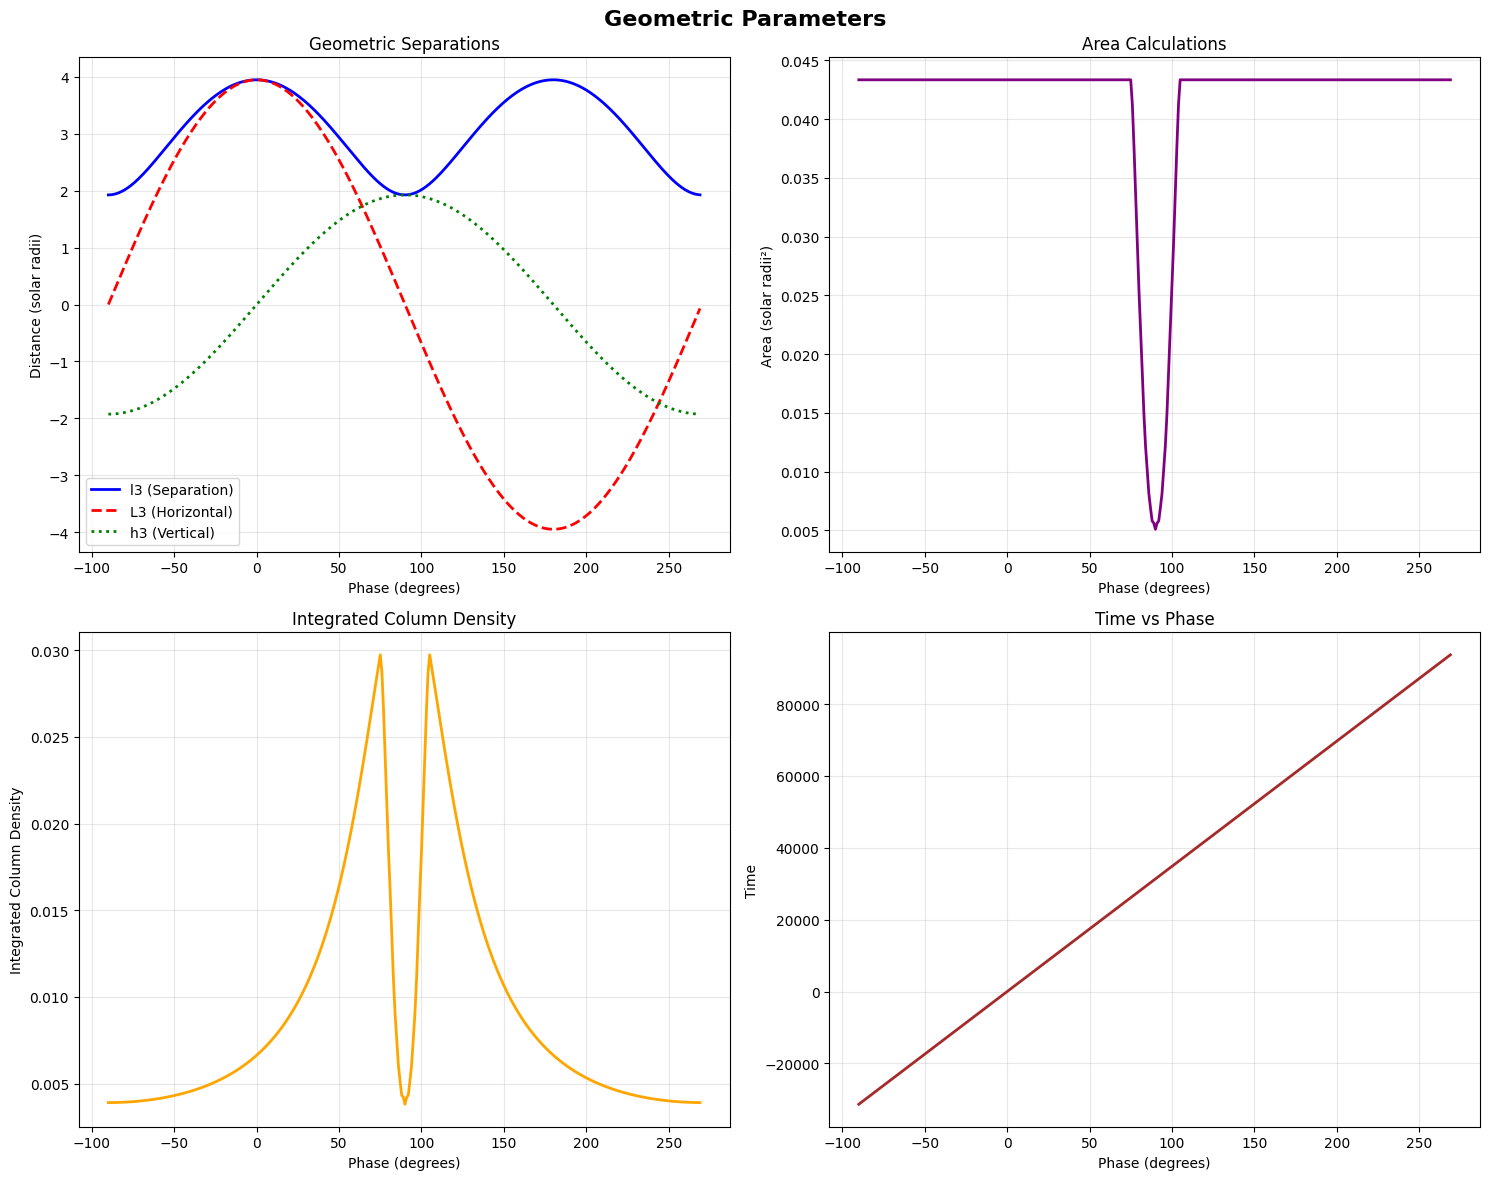

In [8]:
plot_geometric_parameters("./analyses/sim_flux_mcmc_tbabs_15803_av_soft.csv")


Fitting column: nfl_soft_av
Chi-square (no rescaling):
  Phase shift = 0.00000 (fixed)
  Scale factor = 1.00000 (fixed)
  Reduced χ² = 1.914

Fitting column: nfl_soft_cv
Chi-square (no rescaling):
  Phase shift = 0.00000 (fixed)
  Scale factor = 1.00000 (fixed)
  Reduced χ² = 1.483


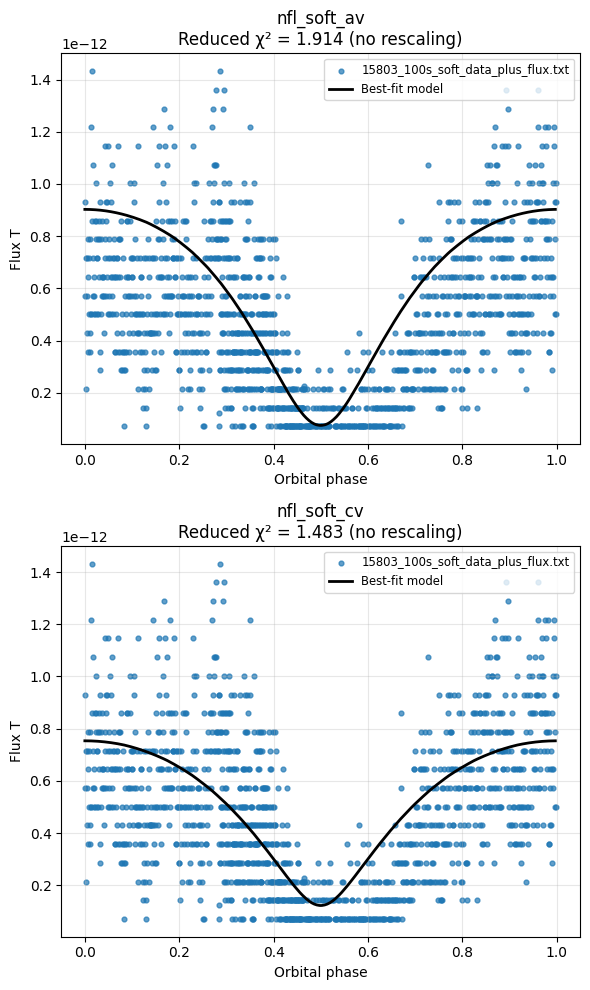

In [4]:
# Fit model to data
sim_df = pd.read_csv("./analyses/sim_flux_interpolate_tbabs_15803_soft.csv")
sim_columns = detect_flux_columns(sim_df)
fit_results = []
for col in sim_columns:
    print(f"\n{'='*60}")
    print(f"Fitting column: {col}")
    print('='*60)
    try:
        shift, scale, chi2 = fit_simulation(df, sim_df, col, rescale=False)
        fit_results.append((shift, scale, chi2))
    except:
        None
if len(sim_columns) == 1:
    # Single column: use original plot
    shift, scale, chi2 = fit_results[0]
    plot_phase(df, None, sim_df, shift, scale, sim_columns[0], chi2, 
                rescaled=False, obs_column_name=obs_column, is_binned=False)
else:
    # Multiple columns: use grid plot
    plot_multi_column_fits(df, None, sim_df, sim_columns, fit_results, 
                            rescaled=False, obs_column_name=obs_column, is_binned=False)

### Broad Band (0.5 - 7.0 KeV)

Loading 1 observation file(s) from ./data/IC_10_X1_LC_CIAO/broad/single
Removed 56 zero/NaN flux data points (1442 remaining)


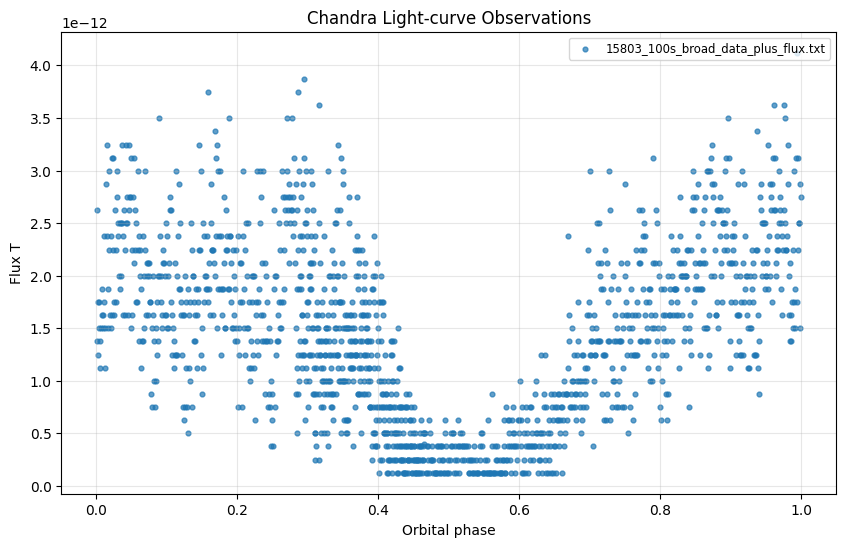

In [2]:
# Plot LC of 15803
obs_column = "flux_t"
time_column = "t_raw"
df = load_data("./data/IC_10_X1_LC_CIAO/broad/single", obs_column = obs_column, time_column = time_column)
n_before = len(df)
df = df[(df['rate'] != 0) & (df['rate'].notna())].reset_index(drop=True)
n_removed = n_before - len(df)
if n_removed > 0:
    print(f"Removed {n_removed} zero/NaN flux data points ({len(df)} remaining)")
plot_phase(df, None, obs_column_name = obs_column)

In [6]:
# Generate Model LC
os.system("python xrb_lightcurve.py \
--flux_method interpolate \
--flux_csv ./analyses/flux_vs_nH_tbabs_15803_broad.csv \
--output ./analyses/sim_flux_interpolate_tbabs_15803_broad.csv \
--i0 20.0 --lam 0.533551 --lam2 0.533551 --r 0.01 --R 2.0 --converge-rmax")

Starting XRB Lightcurve Simulation...
Parameters:
  r (emitter radius): 0.01 solar radii
  R (companion radius): 2.0 solar radii
  d1 (emitter separation): 11.0 solar radii
  d2 (companion separation): 8.0 solar radii
  gma0 (starting phase): -90.0 degrees
  i0 (inclination): 20.0 degrees
  dth (orbital increment): 1.0 degrees
  d2h (polar cell size): 6.0 degrees
  dz (LOS step size): 0.1
  Rmax (LOS cutoff): 38.0
  converge_rmax: True
  n_jobs (parallel workers): 1
  flux_method: interpolate
  flux_csv: ./analyses/flux_vs_nH_tbabs_15803_broad.csv
  flux_type: erg
  lam: 0.533551
  lam2: 0.533551
  Output file: ./analyses/sim_flux_interpolate_tbabs_15803_broad.csv

Detected energy bands in CSV: broad

Simulation completed! Results saved to ./analyses/sim_flux_interpolate_tbabs_15803_broad.csv
Total data points: 360
Phase range: -90.00 to 269.00 degrees


0


Fitting column: nfl_broad_av
Chi-square (no rescaling):
  Phase shift = 0.00000 (fixed)
  Scale factor = 1.00000 (fixed)
  Reduced χ² = 4.334

Fitting column: nfl_broad_cv
Chi-square (no rescaling):
  Phase shift = 0.00000 (fixed)
  Scale factor = 1.00000 (fixed)
  Reduced χ² = 4.696


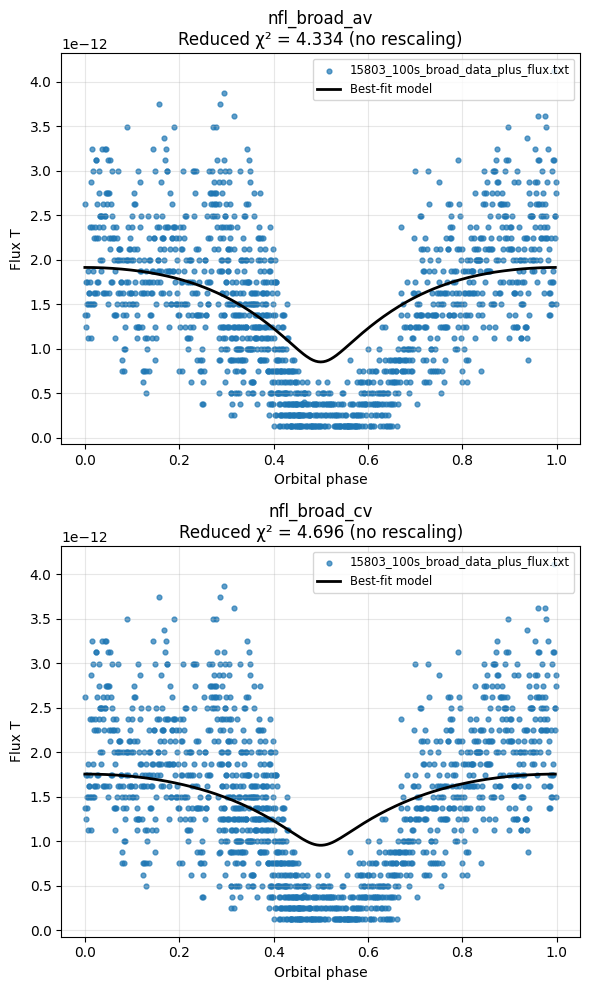

In [7]:
# Fit model to data
sim_df = pd.read_csv("./analyses/sim_flux_interpolate_tbabs_15803_broad.csv")
sim_columns = detect_flux_columns(sim_df)
fit_results = []
for col in sim_columns:
    print(f"\n{'='*60}")
    print(f"Fitting column: {col}")
    print('='*60)
    try:
        shift, scale, chi2 = fit_simulation(df, sim_df, col, rescale=False)
        fit_results.append((shift, scale, chi2))
    except:
        None
if len(sim_columns) == 1:
    # Single column: use original plot
    shift, scale, chi2 = fit_results[0]
    plot_phase(df, None, sim_df, shift, scale, sim_columns[0], chi2, 
                rescaled=False, obs_column_name=obs_column, is_binned=False)
else:
    # Multiple columns: use grid plot
    plot_multi_column_fits(df, None, sim_df, sim_columns, fit_results, 
                            rescaled=False, obs_column_name=obs_column, is_binned=False)

## Deriving estimates of constants from best-fits

Loading 1 observation file(s) from ./data/IC_10_X1_LC_CIAO/broad/single
Removed 56 zero/NaN flux data points (1442 remaining)


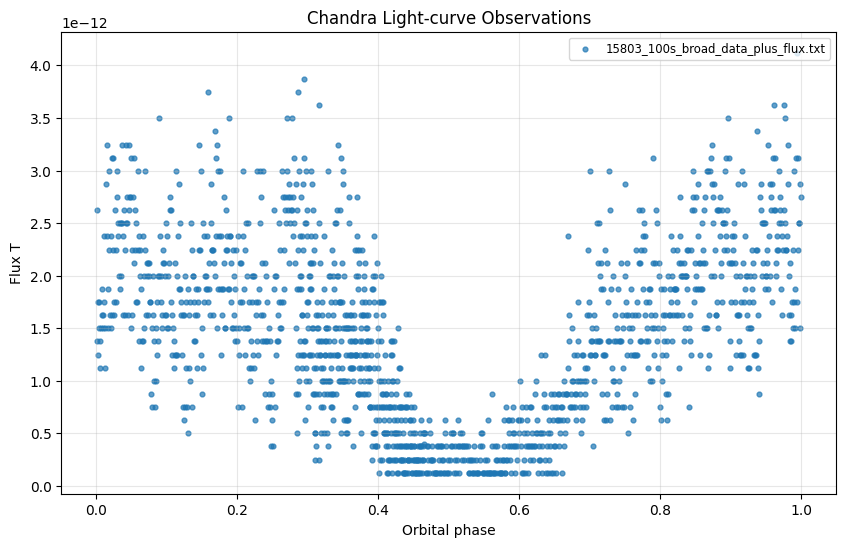

In [6]:
# Plot broad band LC
obs_column = "flux_t"
time_column = "t_raw"
data = load_data("./data/IC_10_X1_LC_CIAO/broad/single", obs_column = obs_column, time_column = time_column)
n_before = len(data)
data_df = data[(data['rate'] != 0) & (data['rate'].notna())].reset_index(drop=True)
n_removed = n_before - len(data_df)
if n_removed > 0:
    print(f"Removed {n_removed} zero/NaN flux data points ({len(data_df)} remaining)")
plot_phase(data_df, None, obs_column_name = obs_column)

Phase binning: 1442 points -> 149 bins (avg 9.6 points/bin)
Chi-square (no rescaling):
  Phase shift = 0.00000 (fixed)
  Scale factor = 1.00000 (fixed)
  Reduced χ² = 3.070


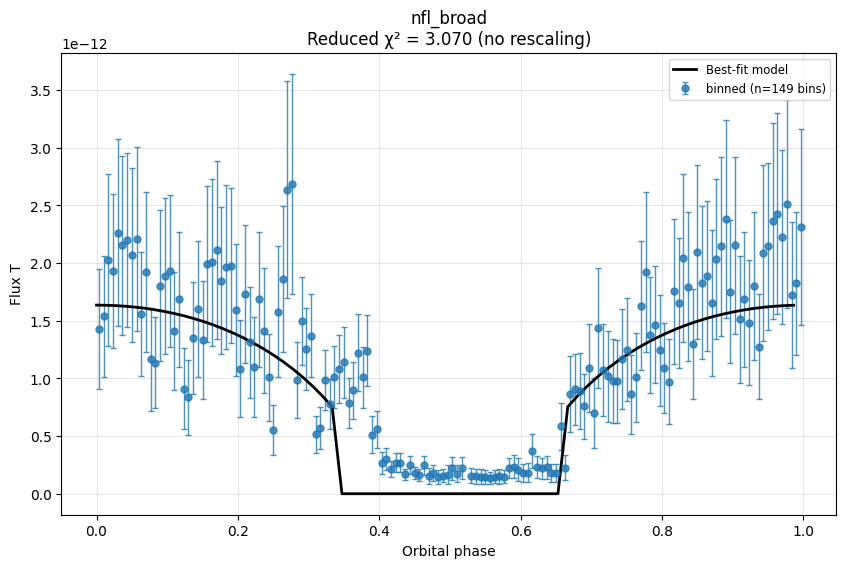

In [8]:
# Smooth powerlaw wind model
wind_params = {"Rb": 7.711251, "p": 7.426900, "Delta": 2}
sim_df = simulate_lightcurve(
        r=0.008074,
        R=2.582077,
        d1=3.004693,
        d2=0.0,
        gma0=-90,
        i0=14.298801,
        dth=5,
        d2h=6,
        dz=0.5,
        verbose=False,
        n_jobs=7,
        flux_method="interpolate",
        flux_csv_path="./analyses/flux_vs_nH_tbabs_15803_broad.csv",
        flux_type="erg",
        lam=0.533545,
        Rmax=None,
        converge_rmax=True,
        wind_model="smooth_pl",
        wind_params=wind_params,
    )
df = phase_bin_data(
    data_df,
    n_bins=150,
    min_points_per_bin=5,
    rate_column='rate',
    error_column='error',
    verbose=True
)
is_binned = True
sim_columns = detect_flux_columns(sim_df)
shift, scale, chi2 = fit_simulation(df, sim_df, sim_columns[0], rescale=False)
plot_phase(df, None, sim_df, shift, scale, sim_columns[0], chi2,
            rescaled=False, obs_column_name=obs_column, is_binned=is_binned)

In [9]:
compute_surface_density(sim_df, lam=0.553545, R_star = 2.582, wind_model = "smooth_pl", wind_params=wind_params)

211956132335.83328

In [3]:
# Phase bin data and write to file
bin_df = phase_bin_data(
    df,
    n_bins=150,
    min_points_per_bin=5,
    rate_column='rate',
    error_column='error',
    verbose=True
)
bin_df.head()

Phase binning: 1442 points -> 149 bins (avg 9.6 points/bin)


,phase,rate,error,n_points,obs
0,0.003333,1.428202e-12,5.171703e-13,8,binned
1,0.010000,1.536959e-12,5.214859e-13,9,binned
2,0.016667,2.026179e-12,7.426484e-13,8,binned
3,0.023333,1.930900e-12,6.654750e-13,9,binned
4,0.030000,2.264575e-12,8.116362e-13,8,binned


In [4]:
bin_df.to_csv("~/Desktop/IC10_X1_15803_broad_binned.txt",sep="")

,rate,time,error,phase,obs
0,8.714808e-13,5.317035e+08,8.714808e-13,0.283627,15803_100s_broad_data_plus_flux.txt
1,1.123766e-12,5.317036e+08,1.123766e-12,0.284424,15803_100s_broad_data_plus_flux.txt
2,4.994513e-13,5.317037e+08,4.994513e-13,0.285221,15803_100s_broad_data_plus_flux.txt
3,8.740398e-13,5.317038e+08,8.740398e-13,0.286019,15803_100s_broad_data_plus_flux.txt
4,1.248628e-12,5.317039e+08,1.248628e-12,0.286816,15803_100s_broad_data_plus_flux.txt
